<a href="https://colab.research.google.com/github/hyperdbio/Android-inject/blob/master/ex09_RNN_%EC%98%81%ED%99%94%EB%A6%AC%EB%B7%B0%ED%95%99%EC%8A%B5%ED%95%98%EA%B8%B0(%EA%B0%90%EC%84%B1%EB%B6%84%EC%84%9D).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 목표
- 네이버영화리뷰데이터를 기반으로 감성 분석 실습을 진행해보자
- RNN 계열 모델을 이해해보자
- Text 데이터 처리 방법에 대해 이해해보자

In [10]:
# gpu 연결
# 드라이브 연동
%cd '/content/drive/MyDrive/머신러닝'

/content/drive/MyDrive/머신러닝


### 데이터 불러오기
 - import
 - txt -> read_csv(), '\t' 구분자

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
# delimiter='\t'
train = pd.read_csv('./data/ratings_train.txt', delimiter='\t')
test = pd.read_csv('./data/ratings_test.txt', delimiter='\t')

display(train.head())
display(test.head())

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


,id,document,label
0,6270596,굳 ㅋ,1
1,9274899,GDNTOPCLASSINTHECLUB,0
2,8544678,뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아,0
3,6825595,지루하지는 않은데 완전 막장임... 돈주고 보기에는....,0
4,6723715,3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??,0


In [17]:
# 데이터 크기 확인
train.shape, test.shape
# id: 사용자(고객) 번호(정보)
# document: 리뷰(텍스트) -> 문제 데이터
# label: 정답데이터 (0 부정, 1 긍정)

((150000, 3), (50000, 3))

In [18]:
# 데이터 정보확인
train.info()

# 리뷰 텍스트에 결측치 5개 존재함 -> 삭제 or 채움
# 특정행에 결측치가 있다면 해당 행은 삭제하겠다! (선택)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        150000 non-null  int64 
 1   document  149995 non-null  object
 2   label     150000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.4+ MB


### 데이터 전처리

In [19]:
# 1. 결측치 처리
# inplace=True 결측치 있는 행을 삭제하고, 원본 변수에다가 처리된 데이터 다시 대입
train.dropna(inplace=True)
# train = train.dropna()

In [20]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149995 entries, 0 to 149999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        149995 non-null  int64 
 1   document  149995 non-null  object
 2   label     149995 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.6+ MB


In [21]:
# test도 확인 후, 결측치가 존재하면 해당 행을 삭제해보자!
test.info() # 결측치 3 -> 제거
test.dropna(inplace=True)
# test2 = test.dropna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        50000 non-null  int64 
 1   document  49997 non-null  object
 2   label     50000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.1+ MB


In [22]:
# 2. 데이터 분리
# train, test
# 문제(document), 답(label)
X_train = train['document']
y_train = train['label']
X_test = test['document']
y_test = test['label']

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(149995,) (149995,)
(49997,) (49997,)


In [23]:
X_train.head()

# 텍스트를 pc가 이해할 수 있는 형태로 변형
# 토큰화 -> 수치화

,document
0,아 더빙.. 진짜 짜증나네요 목소리
1,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나
2,너무재밓었다그래서보는것을추천한다
3,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정
4,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...


#### 텍스트 데이터 전처리
- 토큰화, 수치화
- 토큰화: 문서, 문장 특정 기준에 따라 맞춰서 잘라는 행위
      - 글자단위
      - 단어단위(띄어쓰기단위)
      - 형태소단위(명사, 형용사, 동사, 조사, ...): konlpy, kiwi 도구
- 수치화: 잘라낸 토큰을 일정기준에 맞춰서 숫자형태로 변경하는 행위
    - 원핫인코딩, BOW(Bag of Words), TF-IDF
    - 단어빈도 -> Countvectorizer() 클래스
    - 워드임베딩 -> 학습기반으로 수치화하는 방법(데이터의 의미를 담아줄 수 있음, 문맥의 의미를 연결시킬 수 있음)

In [24]:
# 문장 학습용 데이터를 수치로 변경해주는 클래스(도구)
# 쪼개줌(토큰화), 수치화 => 벡터화
from tensorflow.keras.layers import TextVectorization

In [28]:
# 벡터화도구 생성
vect = TextVectorization(max_tokens=5000,
                         output_mode='int',
                         standardize='lower_and_strip_punctuation',
                         output_sequence_length=10)
vect
# X_train, X_test 해당 도구를 통해 데이터 전처리 예정

# max_tokens: 사용할 최대 단어 토큰 수 제한 ( 빈도수 높은 순 기준으로 짤라줌)
# output_mode: 빈도기반으로 랭킹화하기위해서 숫자로 지정
# standardize: 전처리 기능(대문자 -> 소문자, 공백제거)
# output_sequence_length: 모든 문장의 길이를 10으로 통일 -> 길면 자르고, 짧으면 0으로 채워 맞춰줌
# 왜? 샘플들이 모두 같은 순환횟수를 가져야하기 때문
# 10이 항상 정답은 아님, 상황에 따라 변경해주면됨

<TextVectorization name=text_vectorization_3, built=False>

In [ ]:
# ex)
# hell -> ? 'o'
# appl -> ? 'e'
# dadd -> ? 'y'

In [29]:
# 훈련데이터 기반으로 전처리 토큰화 단어사전 구축
# 데이터를 수치화하고, 구조화 하면서 정렬할 기준 단어들이 필요! -> 단어사전
vect.adapt(X_train)

In [30]:
# 단어사전의 수 확인
vect.vocabulary_size()

5000

In [34]:
# 단어 토큰 확인
vect.get_vocabulary()

# 토큰화 기준: 어절(띄어쓰기)
# * 한국어의 경우 어절별로 잘라내면 의미파악이 미흡함
# --> 한국어 형태소 분석: konlpy(okt, kkma, komoran), kiwi
# --> 토큰화 기능, 품사 부착(감성: 형용사, 동사, 명사, 감탄사)

['',
 '[UNK]',
 np.str_('영화'),
 np.str_('너무'),
 np.str_('정말'),
 np.str_('진짜'),
 np.str_('이'),
 np.str_('왜'),
 np.str_('그냥'),
 np.str_('이런'),
 np.str_('더'),
 np.str_('수'),
 np.str_('영화를'),
 np.str_('잘'),
 np.str_('다'),
 np.str_('보고'),
 np.str_('좀'),
 np.str_('영화는'),
 np.str_('영화가'),
 np.str_('그'),
 np.str_('본'),
 np.str_('최고의'),
 np.str_('봤는데'),
 np.str_('ㅋㅋ'),
 np.str_('없는'),
 np.str_('내가'),
 np.str_('이건'),
 np.str_('없다'),
 np.str_('이렇게'),
 np.str_('드라마'),
 np.str_('완전'),
 np.str_('평점'),
 np.str_('이거'),
 np.str_('있는'),
 np.str_('좋은'),
 np.str_('이게'),
 np.str_('참'),
 np.str_('아'),
 np.str_('평점이'),
 np.str_('보는'),
 np.str_('내'),
 np.str_('연기'),
 np.str_('다시'),
 np.str_('그리고'),
 np.str_('역시'),
 np.str_('쓰레기'),
 np.str_('많이'),
 np.str_('것'),
 np.str_('최고'),
 np.str_('난'),
 np.str_('스토리'),
 np.str_('재밌게'),
 np.str_('한'),
 np.str_('없고'),
 np.str_('하는'),
 np.str_('또'),
 np.str_('꼭'),
 np.str_('보면'),
 np.str_('가장'),
 np.str_('아깝다'),
 np.str_('ㅋㅋㅋ'),
 np.str_('ㅠㅠ'),
 np.str_('마지막'),
 np.str_('영

In [36]:
# 단어사전을 기반으로 벡터화 진행
# 토큰화 -> 수치화 (빈도수 기반)
X_train_vec = vect(X_train)
X_train_vec

<tf.Tensor: shape=(149995, 10), dtype=int64, numpy=
array([[  37,  914,    5, ...,    0,    0,    0],
       [   1,    1,    1, ...,    0,    0,    0],
       [   1,    0,    0, ...,    0,    0,    0],
       ...,
       [  35,    1,    1, ...,    0,    0,    0],
       [3429,   84,    1, ...,    0,    0,    0],
       [ 218,    2, 3740, ...,    0,    0,    0]])>

In [40]:
X_train_vec[0]
# output_sequence_length=10
# dtype=int64, output_mode로 설정한 개념
# 벡터 -> 하나의 방향을 가진 데이터들 (1차원 배열의 개념)
# 뒤쪽의 0값은 길이가 짧았기 때문에 추가된 개념(padding)

<tf.Tensor: shape=(10,), dtype=int64, numpy=array([  37,  914,    5,    1, 1077,    0,    0,    0,    0,    0])>

In [41]:
X_test_vec = vect(X_test)
X_test_vec[0]

<tf.Tensor: shape=(10,), dtype=int64, numpy=array([661,  67,   0,   0,   0,   0,   0,   0,   0,   0])>

In [39]:
vect.get_vocabulary()

['',
 '[UNK]',
 np.str_('영화'),
 np.str_('너무'),
 np.str_('정말'),
 np.str_('진짜'),
 np.str_('이'),
 np.str_('왜'),
 np.str_('그냥'),
 np.str_('이런'),
 np.str_('더'),
 np.str_('수'),
 np.str_('영화를'),
 np.str_('잘'),
 np.str_('다'),
 np.str_('보고'),
 np.str_('좀'),
 np.str_('영화는'),
 np.str_('영화가'),
 np.str_('그'),
 np.str_('본'),
 np.str_('최고의'),
 np.str_('봤는데'),
 np.str_('ㅋㅋ'),
 np.str_('없는'),
 np.str_('내가'),
 np.str_('이건'),
 np.str_('없다'),
 np.str_('이렇게'),
 np.str_('드라마'),
 np.str_('완전'),
 np.str_('평점'),
 np.str_('이거'),
 np.str_('있는'),
 np.str_('좋은'),
 np.str_('이게'),
 np.str_('참'),
 np.str_('아'),
 np.str_('평점이'),
 np.str_('보는'),
 np.str_('내'),
 np.str_('연기'),
 np.str_('다시'),
 np.str_('그리고'),
 np.str_('역시'),
 np.str_('쓰레기'),
 np.str_('많이'),
 np.str_('것'),
 np.str_('최고'),
 np.str_('난'),
 np.str_('스토리'),
 np.str_('재밌게'),
 np.str_('한'),
 np.str_('없고'),
 np.str_('하는'),
 np.str_('또'),
 np.str_('꼭'),
 np.str_('보면'),
 np.str_('가장'),
 np.str_('아깝다'),
 np.str_('ㅋㅋㅋ'),
 np.str_('ㅠㅠ'),
 np.str_('마지막'),
 np.str_('영

In [45]:
print(X_test_vec[1])
X_test[1]
# 5000으로 단어의 최대수를 제한한 것에서 포함 =>
# 15만건 리뷰가 그렇게까지 단어에 대한 개수가 많이 출력되지 않음을 알 수 있음

tf.Tensor([1 0 0 0 0 0 0 0 0 0], shape=(10,), dtype=int64)


'GDNTOPCLASSINTHECLUB'

In [50]:
# 크기확인
X_train_vec.shape, X_test_vec.shape

# 타임스텝은 몇일까? 10번
# 특성의 크기 몇일까? 1
# ex) 목소리 -> 78
# ex) 목소리 -> [1,0,0,0,0,0,0,0] , 특성의 크기: 9

(TensorShape([149995, 10]), TensorShape([49997, 10]))

### simpleRNN 모델링
- 입력층 -> input_shape=(순환횟수, 특성수)
    - 순환횟수: 문장의 길이를 결정하는
    토큰 수(시퀀스의 길이)
    - 문장의 길이: 10 고정
    - 특성수: features의 개수(단어를 표현하기 위한 데이터의 크기, 1)
- 중간층 -> simpleRNN -> 64units
- 이진분류 -> units=1, activation='sigmoid'

In [53]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import InputLayer, Dense, SimpleRNN

rnn_model = Sequential()
rnn_model.add(InputLayer(input_shape=(10,1)))
rnn_model.add(SimpleRNN(units=64))
# rnn모델 기본적으로 중간층 활성화 : tanh (기본값)
rnn_model.add(Dense(1, activation='sigmoid'))

# 모델 정보 확인
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# 컴파일
rnn_model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

In [58]:
# 학습
# 검증데이터 분리 20%
# 반복횟수 20
# 배치사이즈 128
# rnn_h

rnn_h = rnn_model.fit(X_train_vec, y_train,
                      epochs=20,
                      validation_split=0.2,
                      batch_size=128)


Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5057 - loss: 0.7006 - val_accuracy: 0.5123 - val_loss: 0.6934
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5084 - loss: 0.6944 - val_accuracy: 0.5110 - val_loss: 0.6944
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5096 - loss: 0.6936 - val_accuracy: 0.5090 - val_loss: 0.6941
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5138 - loss: 0.6935 - val_accuracy: 0.5099 - val_loss: 0.6934
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5139 - loss: 0.6931 - val_accuracy: 0.5041 - val_loss: 0.6954
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5150 - loss: 0.6929 - val_accuracy: 0.5121 - val_loss: 0.6931
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5152 - loss: 0.6928 - val_accuracy: 0.5159 - val_loss: 0.6929
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5174 - loss: 0.6926 - val_accuracy: 0.

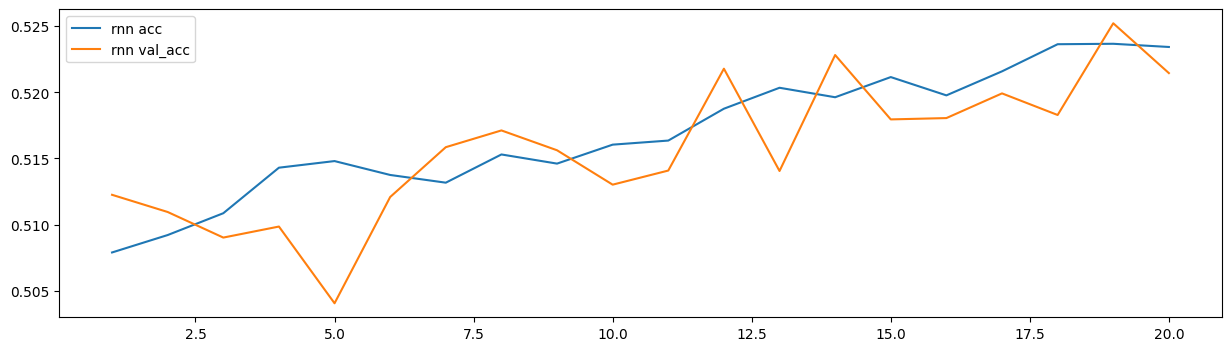

In [70]:
# acc, val_acc 시각화
plt.figure(figsize=(15,4))

plt.plot(range(1,len(rnn_h.history['accuracy'])+1),
               rnn_h.history['accuracy'], label='rnn acc')
plt.plot(range(1,len(rnn_h.history['val_accuracy'])+1),
         rnn_h.history['val_accuracy'], label='rnn val_acc')

plt.plot(range(1,len(rnn_h.history['accuracy'])+1),
               rnn_h.history['accuracy'], label='lstm acc')
plt.plot(range(1,len(rnn_h.history['val_accuracy'])+1),
         rnn_h.history['val_accuracy'], label='lstm val_acc')
plt.legend()
plt.show()

#### 그래프 해석
- 정확도가 향상되며 학습을 진행하고 있으나, 정확도 높은 편은 아님 -> 가장기본적인 rnn 모델 사용했음

#### 모델 성능(정확도)을 높이는 방법
- 1. 더 좋은 성능의 모델을 사용
- 2. 데이터의 질, 양을 향상시키는 방법


#### 기본 RNN의 경우 긴 시퀀스를 가지는 데이터를 효과적으로 학습하기 어려움
- timestep: 10정도 되는 상황
- 문장 길이가 엄청 길지는 않지만, rnn 성능이 조금이라도 길어지면 기억력이 상실
- 순환횟수가 길어질수록 초반에 입력된 단어의 기억데이터 소실되는 기울기소실현상이 발생
- 문장 구성시 초반단어가 후반 예측에 영향을 주는 경우 simpleRNN은 학습의 결과가 좋지 않을 수 있음

#### 보완
- 단점을 보완하기 위해 나온 알고리즘: LSTM(Long Short Term Memory)
    - 장기기억, 단기기억 관리계산이 추가된 모델
    - 단점 : 연산이 복잡해짐, 연산량이 무거워짐
- LSTM의 연산복잡성을 줄인 GRU 모델도 존재


### LSTM
- RNN모델의 기억소실문제를 보완한 모델

In [65]:
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU

In [71]:
# simpleRNN 층 -> LSTM 변경
lstm_model = Sequential() # 뼈대
lstm_model.add(InputLayer(input_shape=(10,1)))
lstm_model.add(LSTM(units=64))
# activation='tanh'
lstm_model.add(Dense(1, activation='sigmoid'))

# 모델 정보 요약
lstm_model.summary() # 기본 모델보다 파라미터 4배가 많은 상황

# 컴파일
lstm_model.compile(loss='binary_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

# 학습
lstm_h = lstm_model.fit(X_train_vec, y_train,
                        validation_split=0.2,
                        epochs=100,
                        batch_size=128)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5158 - loss: 0.6927 - val_accuracy: 0.5235 - val_loss: 0.6912
Epoch 2/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5307 - loss: 0.6908 - val_accuracy: 0.5311 - val_loss: 0.6900
Epoch 3/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5280 - loss: 0.6906 - val_accuracy: 0.5333 - val_loss: 0.6897
Epoch 4/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5321 - loss: 0.6900 - val_accuracy: 0.5344 - val_loss: 0.6895
Epoch 5/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5357 - loss: 0.6895 - val_accuracy: 0.5353 - val_loss: 0.6890
Epoch 6/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5366 - loss: 0.6895 - val_accuracy: 0.5351 - val_loss: 0.6892
Epoch 7/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5369 - loss: 0.6891 - val_accuracy: 0.5328 - val_loss: 0.6893
Epoch 8/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5371 - loss: 0.6889 - val_accu

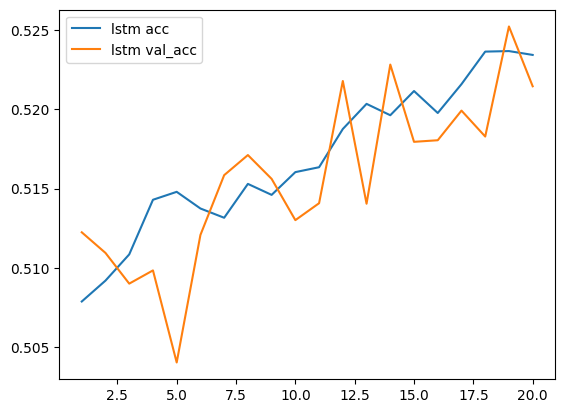

In [72]:
# lstm 모델 시각화 따로 출력하기
# 학습횟수 20 -> 100 변경 해본 상황
plt.figure(figsize=(15,4))
plt.plot(range(1,len(rnn_h.history['accuracy'])+1),
               rnn_h.history['accuracy'], label='lstm acc')
plt.plot(range(1,len(rnn_h.history['val_accuracy'])+1),
         rnn_h.history['val_accuracy'], label='lstm val_acc')


plt.plot(range(1,len(rnn_h.history['accuracy'])+1),
               rnn_h.history['accuracy'], label='gru acc')
plt.plot(range(1,len(rnn_h.history['val_accuracy'])+1),
         rnn_h.history['val_accuracy'], label='gru val_acc')

plt.legend()
plt.show()

#### 그래프 해석
- 기본 rnn모델보다 lstm모델이 조금은 더 성능이 올라온 상태
- 학습 횟수를 더 늘려서보면 lstm 더 성능이 오를것으로 보였으나, 40번 이상으로 넘어갈 경우 오히려 과대적합 현상 발생하는 것을 볼 수 있음
- 나름대로 성능 개선 측면에서 도움이 된것 같음

### GRU 모델링

In [73]:
# simpleRNN 층 -> LSTM 변경 -> GRU
gru_model = Sequential() # 뼈대
gru_model.add(InputLayer(input_shape=(10,1)))
gru_model.add(GRU(units=64))
# activation='tanh'
lstm_model.add(Dense(1, activation='sigmoid'))

# 모델 정보 요약
lstm_model.summary() # 기본 모델보다 파라미터 4배가 많은 상황

# 컴파일
lstm_model.compile(loss='binary_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

# 학습
gru_h = lstm_model.fit(X_train_vec, y_train,
                        validation_split=0.2,
                        epochs=100,
                        batch_size=128)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,887 (198.78 KB)

 Trainable params: 16,963 (66.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 33,924 (132.52 KB)

Epoch 1/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5484 - loss: 0.6802 - val_accuracy: 0.5450 - val_loss: 0.6873
Epoch 2/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5868 - loss: 0.6668 - val_accuracy: 0.5419 - val_loss: 0.6895
Epoch 3/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5924 - loss: 0.6613 - val_accuracy: 0.5392 - val_loss: 0.6921
Epoch 4/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5923 - loss: 0.6582 - val_accuracy: 0.5357 - val_loss: 0.6942
Epoch 5/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5971 - loss: 0.6548 - val_accuracy: 0.5381 - val_loss: 0.6952
Epoch 6/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5954 - loss: 0.6541 - val_accuracy: 0.5382 - val_loss: 0.6982
Epoch 7/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6008 - loss: 0.6502 - val_accuracy: 0.5409 - val_loss: 0.6998
Epoch 8/100
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5999 - loss: 0.6497 - val_accu

#### 그래프 해석
- lstm에서 gru로 넘어왔을 때, 성능이 확 개선된 것 같지는 않음. rnn 보다는 50%이상만큼 성능이 올라온 것으로 봤을때, 조금 더 좋다고 판단.
- 다만, gru 는 lstm 학습하는 시간이 단축이 되었음. 비교적 빠르게 학습이 완료.
- 여러번 모델을 바꿨지만, 확실한 성능개선이 없기에 데이터 측면에서 노력을 해봐야겠음.


In [ ]:
# Textvectorizer -> 빈도수 기반하여 숫자 맵핑 (문장의 문맥 의미 x)
# WordEmbedding -> 단어의 의미적 유사성을 반영하기 위한 학습이 진행된 도구를 사용하는 기법 (문장의 문맥 의미 o)

### 텍스트데이터 질 향상시키기
- WordEmbedding
  - 자연어처리에서 단어를 수치화된 벡터로 처리하는 방법 중 1개
  - 단어를 컴퓨터가 처리할 수 있도록 수치로 변환하는 과정에서 단어의 "의미적 유사성"을 반영하기 위해
  학습하여 벡터화 진행
  - 자연어를 이해하고 분석하는 다양한 작업을 효율적으로 수행하는 기법

In [ ]:
# 자연어? 사람의 말, 언어 ( 한국어, 영어, 중국어 등)
# <-> 인공어: 프로그래밍 언어, 임베디드 언어

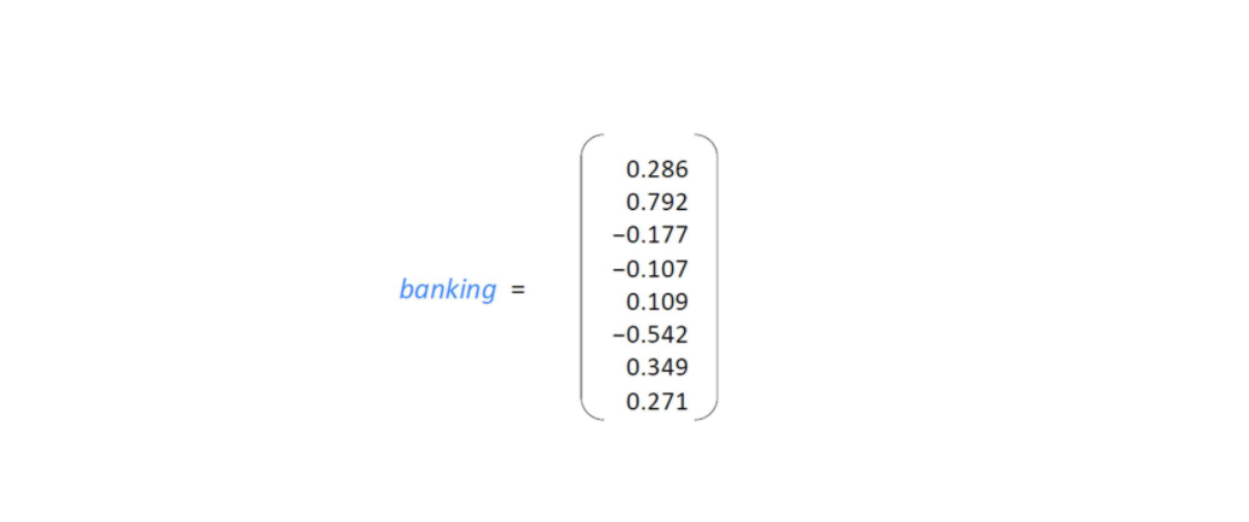

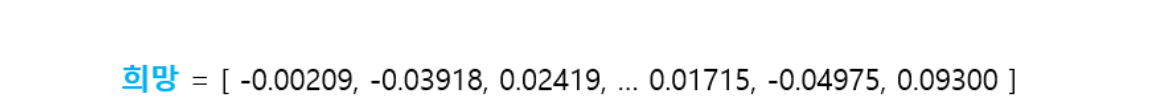

### RNN 계열 모델 여러층 쌓아보기
 - RNN계열의 레이어는 기본적으로 다수입력, 단일출력 구조
 - 여러층으로 쌓는다면 이전 레이어를 다수 입력, 다수출력 구조로 변경
 - return_sequences = True, False (기본값)
    - False: 다수입력, 단일출력 -> 마지막 시점의 출력만 반환 -> 최종예측값만 필요할 때 사용 (예: 단어토큰 여러개를 입력받아 감성분석)


In [83]:
# LSTM 모델(여러층)에 워드임베딩 조합하여 결과 출력

Embeddingm_model = Sequential()
Embeddingm_model.add(Embedding(5000, 50)) # 사용하는 단어사전의 수, 한 단어를 인식할 숫자벡터의 크기
Embeddingm_model.add(LSTM(64, return_sequences=True)) # 다수입력 다수출력 -> 다음 순환신경망 전달
Embeddingm_model.add(LSTM(64))
Embeddingm_model.add(Dense(1, activation='sigmoid'))
Embeddingm_model.compile(loss='binary_crossentropy',
                        optimizer='adam',
                        metrics=['accuracy'])
emb_h = Embeddingm_model.fit(X_train_vec, y_train,
                            validation_split=0.2,
                            epochs=20,
                            batch_size=128)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6916 - loss: 0.5442 - val_accuracy: 0.7643 - val_loss: 0.4578
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7664 - loss: 0.4429 - val_accuracy: 0.7629 - val_loss: 0.4554
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7751 - loss: 0.4254 - val_accuracy: 0.7665 - val_loss: 0.4542
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7813 - loss: 0.4133 - val_accuracy: 0.7620 - val_loss: 0.4610
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7887 - loss: 0.3954 - val_accuracy: 0.7610 - val_loss: 0.4765
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7958 - loss: 0.3793 - val_accuracy: 0.7623 - val_loss: 0.4845
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8048 - loss: 0.3666 - val_accuracy: 0.7508 - val_loss: 0.4999
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8100 - loss: 0.3532 - val_accuracy: 

In [93]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [96]:
# ----------------------
# 1. 데이터 불러오기
# ----------------------
max_features = 5000   # 단어 사전 크기
maxlen = 200          # 시퀀스 길이

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test  = pad_sequences(x_test, maxlen=maxlen)

# ----------------------
# 2. 첫 번째 모델 (기본 LSTM)
# ----------------------
model1 = Sequential()
model1.add(Embedding(max_features, 128, input_length=maxlen))
model1.add(LSTM(64))
model1.add(Dense(1, activation='sigmoid'))

model1.compile(loss='binary_crossentropy',
               optimizer='adam',
               metrics=['accuracy'])

emb_h = model1.fit(x_train, y_train,
                   epochs=5,  # 테스트라 5로 줄임
                   batch_size=64,
                   validation_split=0.2)

# ----------------------
# 3. 두 번째 모델 (더 깊은 LSTM)
# ----------------------
model2 = Sequential()
model2.add(Embedding(max_features, 128, input_length=maxlen))
model2.add(LSTM(128, return_sequences=True))   # 중간 출력 반환
model2.add(LSTM(64))                           # 두 번째 LSTM
model2.add(Dense(1, activation='sigmoid'))

model2.compile(loss='binary_crossentropy',
               optimizer='adam',
               metrics=['accuracy'])

emb2_ = model2.fit(x_train, y_train,
                   epochs=5,
                   batch_size=64,
                   validation_split=0.2)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6788 - loss: 0.5735 - val_accuracy: 0.8464 - val_loss: 0.3663
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8719 - loss: 0.3138 - val_accuracy: 0.8658 - val_loss: 0.3176
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9141 - loss: 0.2265 - val_accuracy: 0.8602 - val_loss: 0.3326
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9345 - loss: 0.1745 - val_accuracy: 0.8648 - val_loss: 0.3467
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9426 - loss: 0.1538 - val_accuracy: 0.8464 - val_loss: 0.3834
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.6578 - loss: 0.5965 - val_accuracy: 0.8388 - val_loss: 0.3781
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8640 - loss: 0.3342 - val_accuracy: 0.8402 - val_loss: 0.3647
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8952 - loss: 0.2612 - val_accuracy: 0.8708 - val

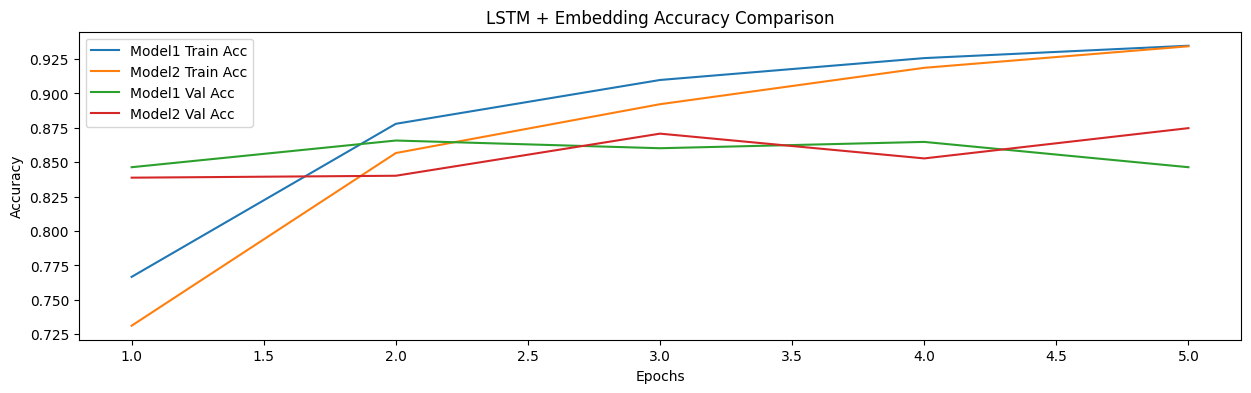

In [97]:
# LSTM + emb 모델 시각화 출력
# 학습횟수 20

plt.figure(figsize=(15,4))

plt.plot(range(1, len(emb_h.history['accuracy'])+1),
         emb_h.history['accuracy'], label='Model1 Train Acc')
plt.plot(range(1, len(emb2_.history['accuracy'])+1),
         emb2_.history['accuracy'], label='Model2 Train Acc')

# Validation Accuracy
plt.plot(range(1, len(emb_h.history['val_accuracy'])+1),
         emb_h.history['val_accuracy'], label='Model1 Val Acc')
plt.plot(range(1, len(emb2_.history['val_accuracy'])+1),
         emb2_.history['val_accuracy'], label='Model2 Val Acc')

plt.title("LSTM + Embedding Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### 그래프 해석
 - 단일lstm + embedding을 통해 성능 개선이 되었지만, 더 확실하게 하기 위한 노력을 진행한 결과
 - 다층 lstm + embedding을 통해 80% 이상의 성능을 확인할 수 있음! 굉장히 학습이 잘된 편
 - 상황에 따라 다르겠지만, 해당 데이터에 있어서는 다층이고 임베딩기술이 적용될때 적절하게 학습이 이루어짐.

In [78]:
from tensorflow.keras.layers import Embedding # 임베딩 레이어

In [81]:
# LSTM 모델에 워드임베딩
Embeddingm_model = Sequential()

# 임베딩 레이어 추가
Embeddingm_model.add(Embedding(5000, 50))
# 단어사전의 수 : 우리가 사용할 전처리 단어사전의 수와 동일하게 맞추고 감 (5000)
# 벡터의 크기: 한 단어마다 50개의 실수값으로 표현 (사용자가 정의하는 값, 50)
# 벡터 내부의 수치는 embedding 도구를 통해서 결정된 값이 출력된 것
# -- 단어/문장 간 관련도 계산 -> 수치화 (실수형태)
# 단어 한개를 표현하기 위한 크기값: 50 -> 특성의 개수 50인 것

# LSTM 레이어는 앞에서 오는 embedding 레이어의 출력을 받아 자동으로 input_shape으로 사용
# (시퀀스 길이, 50) == (timestep, 50)
Embeddingm_model.add(LSTM(64))
Embeddingm_model.add(Dense(1, activation='sigmoid'))

# 정보요약
Embeddingm_model.summary()

# 컴파일
# 학습
Embeddingm_model.compile(loss='binary_crossentropy',
                        optimizer='adam',
                        metrics=['accuracy'])
emb_h = Embeddingm_model.fit(X_train_vec, y_train,
                            validation_split=0.2,
                            epochs=20,
                            batch_size=128)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6855 - loss: 0.5487 - val_accuracy: 0.7647 - val_loss: 0.4584
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7680 - loss: 0.4427 - val_accuracy: 0.7625 - val_loss: 0.4559
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7791 - loss: 0.4234 - val_accuracy: 0.7639 - val_loss: 0.4573
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7835 - loss: 0.4091 - val_accuracy: 0.7641 - val_loss: 0.4600
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7907 - loss: 0.3952 - val_accuracy: 0.7650 - val_loss: 0.4799
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7976 - loss: 0.3835 - val_accuracy: 0.7581 - val_loss: 0.4862
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8042 - loss: 0.3684 - val_accuracy: 0.7601 - val_loss: 0.4999
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8090 - loss: 0.3569 - val_accuracy: 0.

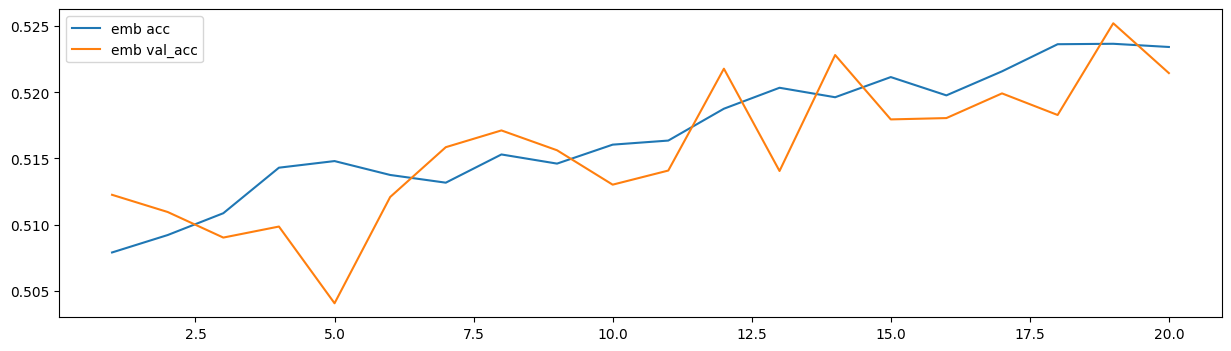

In [82]:
# lstm + emb 모델 시각화 따로 출력하기
# 학습횟수 20
plt.figure(figsize=(15,4))

plt.plot(range(1,len(rnn_h.history['accuracy'])+1),
               rnn_h.history['accuracy'], label='emb acc')
plt.plot(range(1,len(rnn_h.history['val_accuracy'])+1),
         rnn_h.history['val_accuracy'], label='emb val_acc')

plt.legend()
plt.show()

#### 그래프 해석
- 단순 lstm모델보다 lstm과 embedding을 동시 적용한 모델이 확실히 성능이 개선된 것을 알 수 있음!
- 단순 빈도수 기반 숫자 맵핑이 아니라 문장의 의미를 잘 나타낼 수 있는 수치화 기법이 필요함
- 반복횟수가 더 많아지면, 과대적합 현상이 있을 수 있을것도 같음.
- 이 보다 더 높이고 싶으면 어떻게 할까?